# Customer Segmentation and Revenue Insights for an Online Retail Business

**RFM Analysis, Customer Segmentation, and Business Recommendations**

## 1. Introduction and Business Context

### 1.1 Business Context

This project analyzes transactional data from an online retail company in order to better understand customer purchasing behavior and identify actionable business opportunities.

The company operates in the e-commerce sector and aims to improve customer targeting, retention, and revenue generation. By analyzing customer transactions, this project seeks to uncover meaningful patterns in purchasing behavior and support more informed marketing decisions.

### 1.2 Project Objectives

The main objective of this project is to perform customer analytics using transaction-level retail data.

More specifically, the project aims to:

- clean and prepare the dataset for analysis
- explore customer purchasing patterns
- perform RFM analysis to evaluate customer value
- segment customers into meaningful groups
- generate business insights and recommendations
- build a dashboard to communicate findings clearly

### 1.3 Key Business Questions

This project focuses on the following business questions:

1. Who are the most valuable customers?
2. Which customer segments can be identified based on purchase behavior?
3. Are there customers at risk of becoming inactive?
4. How is revenue distributed across customers, products, and countries?
5. What actions could help improve customer retention and revenue?

## 2. Dataset Overview

### 2.1 Data Source

The dataset used in this project is the "Online Retail" dataset, originally sourced from the UCI Machine Learning Repository.

It contains transactional data from a UK-based online retail company, covering the period from December 2010 to December 2011.

Each row in the dataset represents a single transaction line (i.e., a product purchased within an invoice).
The dataset used in this project is the "Online Retail" dataset, originally sourced from the UCI Machine Learning Repository.

It contains transactional data from a UK-based online retail company, covering the period from December 2009 to December 2011.

Each row in the dataset represents a single transaction line (i.e., a product purchased within an invoice).

The dataset is provided in two separate sheets covering different time periods:

- 2009–2010
- 2010–2011

These two datasets will be combined into a single dataset to allow for a more comprehensive analysis of customer behavior over time.

## 2.2 Description of Variables

The dataset includes the following key variables:

- **InvoiceNo**: Unique identifier for each transaction (invoice number)
- **StockCode**: Unique identifier for each product
- **Description**: Name of the product
- **Quantity**: Number of units purchased per transaction
- **InvoiceDate**: Date and time of the transaction
- **UnitPrice**: Price per unit of the product
- **CustomerID**: Unique identifier for each customer
- **Country**: Country where the customer is located

## 2.3 Initial Observations

At first glance, the dataset appears to contain detailed transactional information, which makes it suitable for customer-level analysis.

However, some potential data quality issues are expected:

- missing values in CustomerID
- negative or zero quantities (possible returns or errors)
- invoice numbers associated with cancellations
- potential outliers in quantity and price

These issues will be addressed during the data cleaning phase.

## 3. Environment Setup and First Look

### 3.1 Libraries importation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display options
pd.set_option('display.max_columns', None)

In [2]:
import os
print(os.getcwd())

/Users/verenankouatchet/Documents/marketing-customer-segmentation/notebooks


In [4]:
print(os.listdir("../data"))

['online_retail_II.xlsx']


### 3.2 Load Dataset

In [11]:
file_path = "../data/online_retail_II.xlsx"

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

# chargeons les deux feuilles
df_2009 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
df_2010 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

df = pd.concat([df_2009, df_2010], ignore_index=True)
df.head()

['Year 2009-2010', 'Year 2010-2011']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### 3.3 Data Exploration

In [12]:
df.head()
df.tail()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


### 3.4 Initial Data Exploration observations

The dataset contains over 1 million transaction records, indicating a large volume of data suitable for analysis.

The dataset includes transactional information such as product details, quantities, prices, and customer identifiers.

The InvoiceDate column is already in datetime format, which facilitates time-based analysis.

At this stage, the dataset structure appears suitable for further analysis.

## 4. Data Quality Assessment

The dataset contains over 1 million transaction records, making it suitable for large-scale customer analysis.

Initial data quality observations:

- A significant number of missing values are present in the Customer ID column, which may impact customer-level analysis.
- A small number of missing values are also observed in the Description column.
- The InvoiceDate column is already in datetime format, which facilitates time-based analysis.
- Data types appear mostly appropriate, although Customer ID is stored as a float due to missing values.

These issues will be addressed in the data cleaning phase.

### 4.1 Missing Values

In [13]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

### 4.2 Duplicate Records

In [14]:
df.duplicated().sum()

np.int64(34335)

### 4.3 Cancelled Transactions

In [15]:
df[df["Invoice"].astype(str).str.startswith("C")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


### 4.4 Negative Quantities

In [16]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


### 4.5 Invalid or Zero Prices

In [17]:
df[df["Price"] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


### 4.6 Summary of Data Quality Issues

The data quality assessment revealed several important issues:

- A large number of missing values in the Customer ID column, which prevents customer-level analysis.
- A smaller number of missing values in the Description column.
- A significant number of duplicate records (over 34,000).
- Presence of cancelled transactions identified by invoice numbers starting with "C".
- Negative quantities, likely representing product returns.
- Transactions with zero prices, which may indicate data entry errors or non-revenue transactions.

These issues must be addressed before proceeding with analysis to ensure data reliability.

## 5. Data Cleaning

### 5.0 Let's make a copy of our data before cleaning

In [19]:
df_clean = df.copy()

# verification
df_clean.head()
df_clean.shape

(1067371, 8)

### 5.1 Handling Missing Customer IDs

In [20]:
df_clean = df_clean[df_clean["Customer ID"].notna()]

df_clean["Customer ID"].isnull().sum() #verification

np.int64(0)

### Comment: 
Rows with missing Customer ID values were removed, as they cannot be used for customer-level analysis such as segmentation.

### 5.2 Removing Duplicate Records

In [21]:
df_clean = df_clean.drop_duplicates()

df_clean.duplicated().sum() # verification

np.int64(0)

### Comment: 
Duplicate transactions were removed to avoid bias in the analysis, particularly in revenue and frequency calculations.

### 5.3 Removing Cancelled Transactions

In [22]:
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]

df_clean[df_clean["Invoice"].astype(str).str.startswith("C")] # verification

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


### Comment:

Transactions with invoice numbers starting with "C" were identified as cancellations and removed from the dataset, as they do not represent actual purchases.

### 5.4 Removing Negative Quantities

In [23]:
df_clean = df_clean[df_clean["Quantity"] > 0]

df_clean[df_clean["Quantity"] <= 0] # verification

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


### Comment:

Transactions with negative quantities were removed, as they likely represent product returns rather than actual purchases.

### 5.5 Removing Invalid or Zero Prices

In [24]:
df_clean = df_clean[df_clean["Price"] > 0]

df_clean[df_clean["Price"] <= 0] # verification

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


### Comment:

Transactions with zero or negative prices were removed, as they do not represent valid revenue-generating sales.

### 5.6 Final Dataset Overview 

In [25]:
df_clean.info()

# before and after dataset comparison
print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 53.5+ MB
Before cleaning: (1067371, 8)
After cleaning: (779425, 8)


### Impact of Removing Missing Customer IDs

After removing rows with missing Customer ID values, the dataset size was reduced from 1,067,371 to 779,425 records.

This reduction is expected, as a significant portion of the dataset did not contain customer identifiers. Retaining only valid customer records ensures that subsequent analysis, particularly customer segmentation, is meaningful and reliable.

This cleaned dataset will be used for subsequent analysis, including customer segmentation and RFM modeling.

## 6. Feature Engineering

### 6.1 Creating Transaction-Level Revenue

In [26]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["Price"]

df_clean[["Quantity", "Price", "TotalPrice"]].head() # verification

,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


### Comment:

A new variable, `TotalPrice`, was created to represent the revenue generated by each transaction line. It is calculated as the product of quantity and unit price.

### 6.2 Creating a Customer-Level Dataset

In [27]:
df_clean["Customer ID"].nunique()

df_clean["Customer ID"].head() # verification

0    13085.0
1    13085.0
2    13085.0
3    13085.0
4    13085.0
Name: Customer ID, dtype: float64

### Comment:

Before building customer metrics, the number of unique customers was examined in order to confirm the scope of the customer-level analysis.

### 6.3 Defining the Snapshot Date

In [28]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date 

Timestamp('2011-12-10 12:50:00')

### Comment:

A snapshot date was defined as one day after the most recent transaction in the dataset. This date is used as the reference point for calculating customer recency.

### 6.4 Building RFM Metrics

In [29]:
rfm = df_clean.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).reset_index()

In [30]:
# renaming the RFM columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

In [32]:
# verification 1
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [33]:
# verification 2
rfm.shape

(5878, 4)

### Comments:

A customer-level RFM table was successfully created from the cleaned transactional dataset.

The resulting table contains 5,878 unique customers and includes the three key metrics used in customer segmentation:

- **Recency**: days since the last purchase
- **Frequency**: number of unique invoices
- **Monetary**: total customer spending

This customer-level dataset will be used in the next phase to assign RFM scores and identify meaningful customer segments.

## 7. RFM Analysis

### 7.1 Exploring RFM Distributions

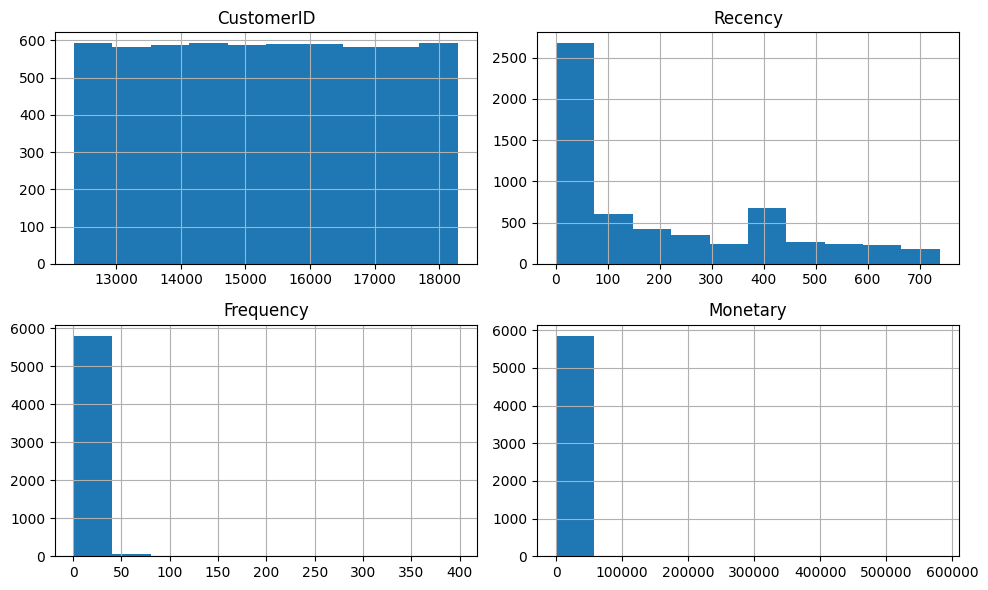

In [34]:
rfm.describe()

rfm.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

### Comment:

The RFM variables were first explored to better understand their distribution and identify potential skewness or concentration patterns before assigning scores. 

### 7.2 Assigning RFM Scores

In [35]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]) # recency score

rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]) # frequency score

rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]) # monetary score

rfm.head() # verification

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,12,77556.46,2,5,5
1,12347.0,2,8,4921.53,5,4,5
2,12348.0,75,5,2019.40,3,4,4
3,12349.0,19,4,4428.69,5,3,5
4,12350.0,310,1,334.40,2,1,2


### Comment:

Each customer was assigned an RFM score from 1 to 5 for each metric.

- **Recency** was scored in reverse order, since lower recency indicates more recent activity.
- **Frequency** and **Monetary** were scored in ascending order, where higher values indicate better customer engagement and value.

### 7.3 Creating RFM Segments

In [36]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm[["CustomerID", "R_Score", "F_Score", "M_Score", "RFM_Score"]].head() # verification

,CustomerID,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,2,5,5,255
1,12347.0,5,4,5,545
2,12348.0,3,4,4,344
3,12349.0,5,3,5,535
4,12350.0,2,1,2,212


### Comment:

The individual R, F, and M scores were combined into a three-digit RFM score in order to summarize each customer's purchasing behavior profile.

### 7.4 — Segmentation

In [38]:
def segment_customer(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"
    elif row["F_Score"] >= 4:
        return "Loyal Customers"
    elif row["R_Score"] >= 4:
        return "Recent Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "At Risk"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head() # verification

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,5,5,255,Loyal Customers
1,12347.0,2,8,4921.53,5,4,5,545,Champions
2,12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,535,Recent Customers
4,12350.0,310,1,334.40,2,1,2,212,At Risk


### 7.5 segments distribution

In [39]:
rfm["Segment"].value_counts() 

Segment
At Risk             1523
Champions           1482
Others              1122
Recent Customers     882
Loyal Customers      869
Name: count, dtype: int64

### Interpretation:

The customer segmentation reveals a diverse distribution across behavioral groups.

- A large number of customers fall into the **Champions** segment, indicating strong engagement and high value.
- A similarly large group is classified as **At Risk**, suggesting potential customer churn and highlighting an important retention opportunity.
- The **Loyal Customers** and **Recent Customers** segments represent customers with growth potential.
- The **Others** segment includes customers with moderate engagement levels.

This distribution suggests that while the company has a strong base of high-value customers, there is also a significant risk of customer loss if no targeted actions are taken.

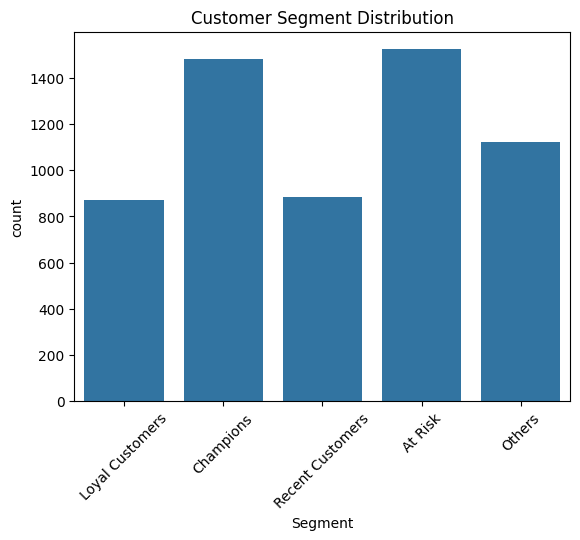

In [41]:
# segments distribution graphic
sns.countplot(data=rfm, x="Segment")
plt.xticks(rotation=45)
plt.title("Customer Segment Distribution")
plt.show()

### Interpretation:

The distribution of customer segments shows that a large proportion of customers are either highly engaged (Champions) or at risk of churn.

This indicates a polarized customer base, where the company has both strong performers and a significant number of customers requiring re-engagement.

The presence of many “At Risk” customers suggests an opportunity for targeted retention strategies.

### 7.6 Customer Segment Insights

In [40]:
rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(1)

,Recency,Frequency,Monetary
Segment,,,
At Risk,459.3,1.3,429.7
Champions,20.4,15.7,8113.6
Loyal Customers,202.9,8.1,3202.1
Others,226.4,2.5,928.6
Recent Customers,26.5,2.3,988.2


### Interpretation:

The analysis of RFM metrics across segments reveals distinct customer behaviors:

- **Champions** are highly valuable customers, with very recent activity, high purchase frequency, and strong spending levels. They represent a key revenue-driving group.
- **At Risk** customers show very low engagement, with long periods since their last purchase and minimal transaction activity. This group represents a potential loss of customers.
- **Loyal Customers** have strong purchasing behavior but are less recent, indicating a possible decline in engagement.
- **Recent Customers** have made purchases recently but have not yet developed strong purchasing habits.
- **Others** represent customers with moderate engagement and lower overall value.

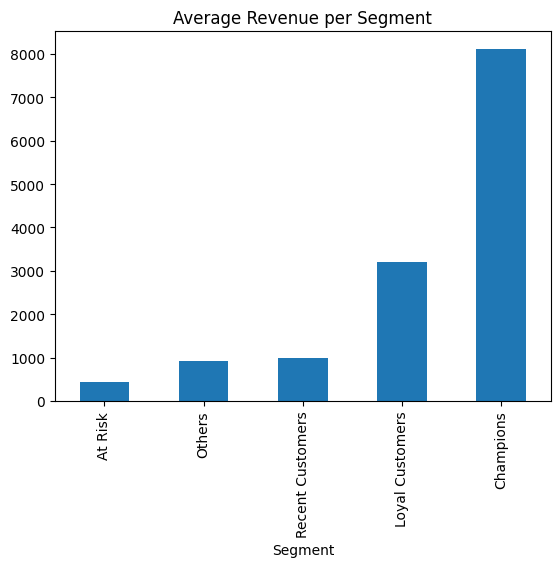

In [42]:
# customer Segment Insights graphic
rfm.groupby("Segment")["Monetary"].mean().sort_values().plot(kind="bar")
plt.title("Average Revenue per Segment")
plt.show()

### Interpretation:

The average revenue per segment highlights a significant disparity in customer value.

Champions generate substantially higher revenue compared to all other segments, confirming their importance to the business.

In contrast, “At Risk” customers contribute very little to overall revenue, indicating low engagement and potential churn.

This reinforces the need to prioritize high-value customers while developing strategies to increase the value of lower-performing segments.

### 7.7 Business Recommendations

Based on the customer segmentation, several marketing strategies can be recommended:

- **Champions**: implement loyalty programs and personalized offers to retain these high-value customers.
- **Loyal Customers**: re-engage through targeted campaigns to prevent churn and maintain their activity.
- **Recent Customers**: nurture with onboarding campaigns and promotions to increase purchase frequency.
- **At Risk**: launch reactivation campaigns, such as discounts or personalized emails, to win back disengaged customers.
- **Others**: use targeted promotions and marketing efforts to increase engagement and move them into higher-value segments.

## 8. Data Export

In [44]:
# export RFM table for Power BI
rfm.to_csv("../data/rfm_table.csv", index=False)

### Comment: 

The final RFM dataset was exported for use in Power BI to create an interactive dashboard.

## Conclusion

This project demonstrates how customer transaction data can be transformed into actionable business insights using RFM analysis.

The segmentation highlights key opportunities for improving customer retention, increasing engagement, and optimizing marketing strategies. 